In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd

%matplotlib widget

In [23]:
# Geometric Distribution


def pmf_geom_distr(p, x_values):
    return np.array([((1 - p) ** (x - 1)) * p for x in x_values])


def cdf_geom_distr(n, p):
    return 1 - (1 - p) ** n


def sim_geom_distr(p, N=10_000):
    U = np.random.uniform(size=N)
    return np.floor(np.log(U) / np.log(1 - p)) + 1

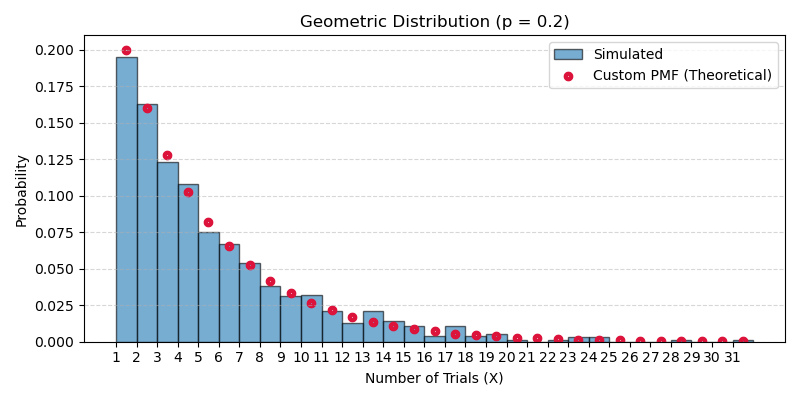

In [24]:
p = 0.2
samples = sim_geom_distr(p, N=1000)


max_simulated_x = int(np.max(samples))
x_axis_values = np.arange(1, max_simulated_x) + 0.5

# Call your custom PMF function with the precise x range
y_theoretical = pmf_geom_distr(p=p, x_values=range(1, max_simulated_x))

# --- PLOTTING ---
plt.figure(figsize=(8, 4))

# Empirical Histogram

plt.hist(
    samples,
    bins=np.arange(1, max_simulated_x + 1, 1),
    density=True,
    alpha=0.6,
    edgecolor="black",
    label="Simulated",
)


plt.scatter(
    x_axis_values,
    y_theoretical,
    marker="$\circledcirc$",
    color="crimson",
    label="Custom PMF (Theoretical)",
)

plt.title(f"Geometric Distribution (p = {p})")
plt.xlabel("Number of Trials (X)")
plt.ylabel("Probability")
plt.xticks(x_axis_values - 0.5)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## Dice Distribution 

In [25]:
def plot_dice_distribution(
    samples, x_vals, x_prob, title="Dice Distribution", samples_are_indices=False
):
    samples = np.asarray(samples)
    x_vals = np.asarray(x_vals)
    x_prob = np.asarray(x_prob)

    if samples_are_indices:
        samples = x_vals[samples.astype(int)]

    bin_edges = np.arange(np.min(x_vals), np.max(x_vals) + 2) - 0.5

    plt.figure(figsize=(8, 4))

    plt.hist(
        samples,
        bins=bin_edges,
        density=True,
        alpha=0.6,
        edgecolor="black",
        label="Simulated",
    )

    plt.scatter(
        x_vals,
        x_prob,
        marker="$\\circledcirc$",
        color="crimson",
        label="Theoretical PMF",
    )

    plt.title(title)
    plt.xlabel("Dice Outcome (X)")
    plt.ylabel("Probability")
    plt.xticks(x_vals)
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

In [26]:
# Distribution
N = 10_000

x_vals = np.array([1, 2, 3, 4, 5, 6])
x_prob = np.array([7 / 48, 5 / 48, 1 / 8, 1 / 16, 1 / 4, 5 / 16])

#### Crude Method 

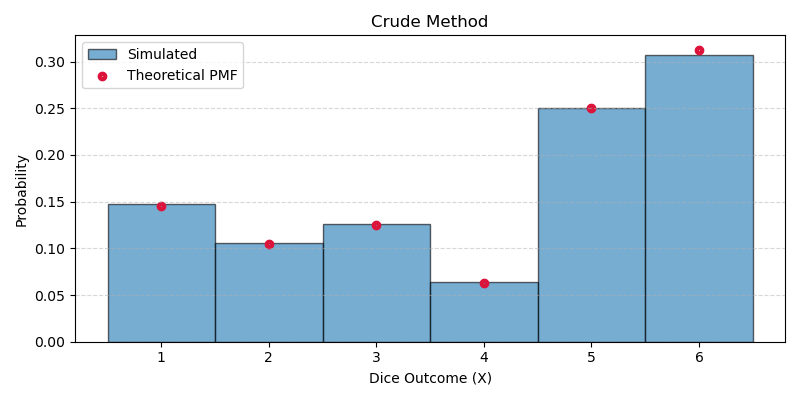

In [27]:
samples = x_vals[np.searchsorted(np.cumsum(x_prob), np.random.uniform(size=N))]

plot_dice_distribution(samples, x_vals, x_prob, "Crude Method")

#### Rejection Method

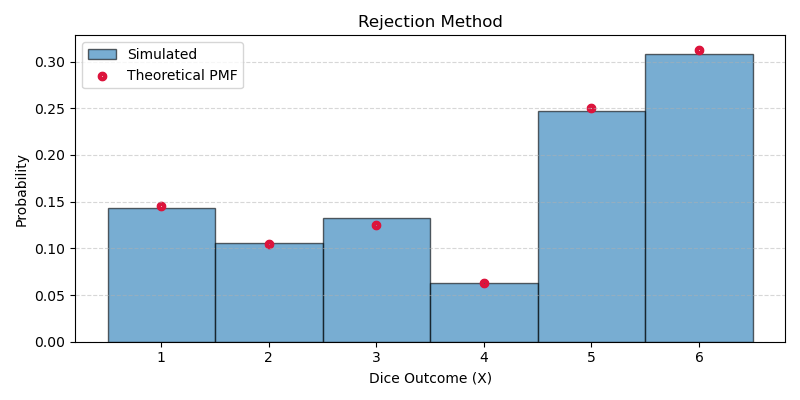

In [28]:
def sample_dice_rejection(n=N):
    samples = []
    max_prob = np.max(x_prob)

    while len(samples) < n:
        proposal_idx = np.random.randint(0, len(x_vals))
        u = np.random.uniform()

        if u <= x_prob[proposal_idx] / max_prob:
            samples.append(x_vals[proposal_idx])

    return np.array(samples)


rejection_samples = sample_dice_rejection(N)
rejection_sampled_indices = rejection_samples - 1

rejection_freq = np.array([np.mean(rejection_samples == x) for x in x_vals])
rejection_freq

plot_dice_distribution(rejection_samples, x_vals, x_prob, "Rejection Method")

#### Alias Method

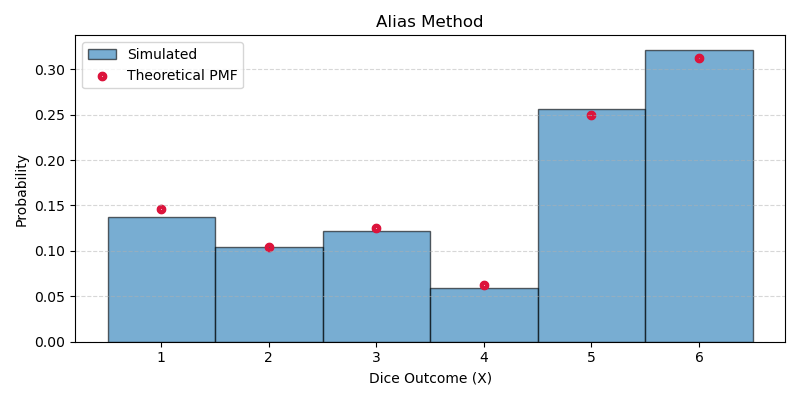

In [29]:
def setup_alias_method(probabilities):
    number_of_buckets = len(probabilities)

    # Scale the bucket height
    bucket_height = probabilities * number_of_buckets

    cutoff = np.ones(number_of_buckets)
    alias = np.arange(number_of_buckets)

    poor = [i for i in range(number_of_buckets) if bucket_height[i] < 1]
    rich = [i for i in range(number_of_buckets) if bucket_height[i] >= 1]

    while poor and rich:
        poor_bucket = poor.pop()
        rich_bucket = rich.pop()

        cutoff[poor_bucket] = bucket_height[poor_bucket]
        alias[poor_bucket] = rich_bucket

        # The rich bucket gives away jst enough to fill the poor bucket
        amount_given_away = 1 - bucket_height[poor_bucket]
        bucket_height[rich_bucket] -= amount_given_away

        if bucket_height[rich_bucket] < 1:
            poor.append(rich_bucket)
        else:
            rich.append(rich_bucket)

    return cutoff, alias


def sample_one_alias(x_vals, cutoff, alias):
    bucket = np.random.randint(0, len(x_vals))
    coin_flip = np.random.uniform()

    if coin_flip <= cutoff[bucket]:
        return x_vals[bucket]

    return x_vals[alias[bucket]]


alias_cutoff, alias = setup_alias_method(x_prob)
alias_samples = np.array(
    [sample_one_alias(x_vals, alias_cutoff, alias) for _ in range(N)]
)
alias_sampled_indices = alias_samples - 1

alias_freq = np.array([np.mean(alias_samples == x) for x in x_vals])
alias_freq

plot_dice_distribution(alias_samples, x_vals, x_prob, "Alias Method")

# Continuous Distributions

In [30]:
def plot_continuous_distribution(
    samples, x_vals, pdf_vals, title="Continuous Distribution", xlabel="Value (X)"
):

    samples = np.asarray(samples)
    x_vals = np.asarray(x_vals)
    pdf_vals = np.asarray(pdf_vals)

    plt.figure(figsize=(8, 4))

    # Plot sampleed histogram
    plt.hist(
        samples,
        bins=50,
        density=True,
        alpha=0.6,
        color="skyblue",
        edgecolor="steelblue",
        label="Simulated",
    )

    # Plot theoretical  density funcitons
    plt.plot(
        x_vals,
        pdf_vals,
        color="crimson",
        linewidth=2.5,
        label="Theoretical PDF",
    )

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Density")
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

#### Expoenntial Distribution

--- Kolmogorov-Smirnov Test Results ---
KS Statistic (D): 0.01126
P-value:          0.15688


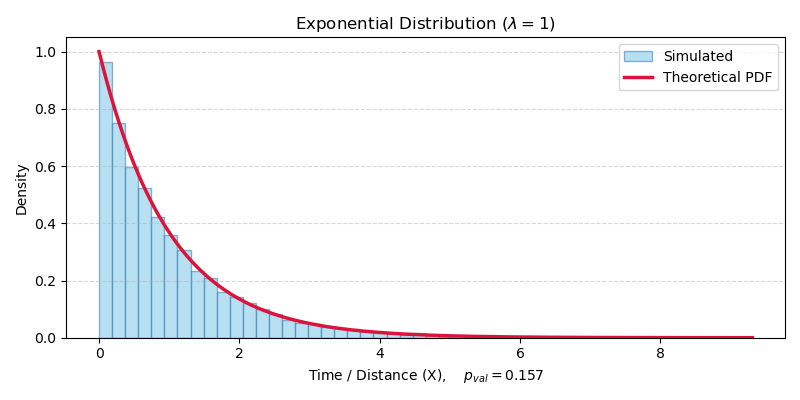

In [31]:
N = 10_000
lambd = 1

samples_exp = -np.log(np.random.sample(N)) / lambd

x_dense = np.linspace(0, np.max(samples_exp), 1000)
theoretical_pdf = lambd * np.exp(-lambd * x_dense)



# KS test
theoretical_distribution = stats.expon(scale=1 / lambd)

# Perform the KS Test by passing the variable directly
ks_statistic, p_value = stats.kstest(samples_exp, theoretical_distribution.cdf)

print("--- Kolmogorov-Smirnov Test Results ---")
print(f"KS Statistic (D): {ks_statistic:.5f}")
print(f"P-value:          {p_value:.5f}")


plot_continuous_distribution(
    samples=samples_exp,
    x_vals=x_dense,
    pdf_vals=theoretical_pdf,
    title=f"Exponential Distribution ($\\lambda = {lambd}$)",
    xlabel=f"Time / Distance (X), $\quad p_{{val}} = {p_value:.3f}$",
)

--- KS Test Results for Z_1 (Cosine stream) ---
KS Statistic (D): 0.00779
P-value:          0.57632

--- KS Test Results for Z_2 (Sine stream) ---
KS Statistic (D): 0.01112
P-value:          0.16749


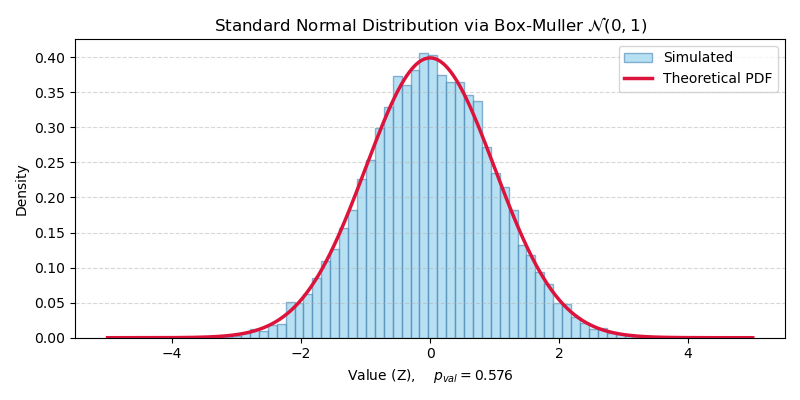

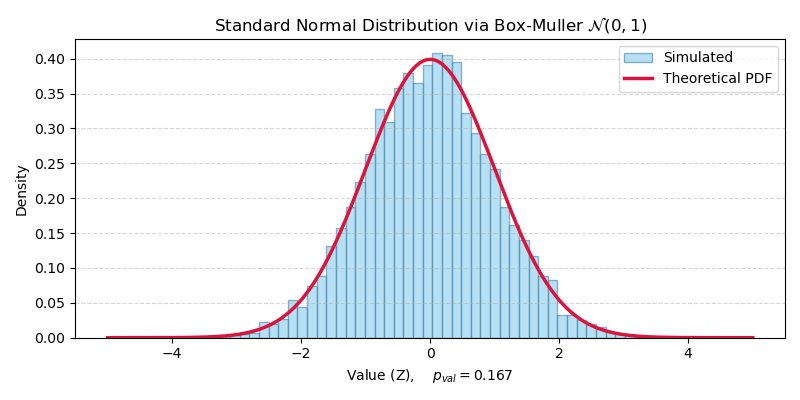

In [32]:
U_1 = np.random.uniform(0, 1, N)
U_2 = np.random.uniform(0, 1, N)

# Using the Box-Muller Transform equations
height = np.sqrt(-2 * np.log(U_1))
Z_1 = height * np.cos(2 * np.pi * U_2)
Z_2 = height * np.sin(2 * np.pi * U_2)


# Theoretical pdf vals 
x_dense = np.linspace(-5, 5, 1000)
theoretical_normal = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * (x_dense) ** 2)




# KS Test
theoretical_normal_dist = stats.norm()


ks_stat_1, p_val_1 = stats.kstest(Z_1, theoretical_normal_dist.cdf)

ks_stat_2, p_val_2 = stats.kstest(Z_2, theoretical_normal_dist.cdf)

# Print the results
print("--- KS Test Results for Z_1 (Cosine stream) ---")
print(f"KS Statistic (D): {ks_stat_1:.5f}")
print(f"P-value:          {p_val_1:.5f}")

print("\n--- KS Test Results for Z_2 (Sine stream) ---")
print(f"KS Statistic (D): {ks_stat_2:.5f}")
print(f"P-value:          {p_val_2:.5f}")




plot_continuous_distribution(
    samples=Z_1,
    x_vals=x_dense,
    pdf_vals=theoretical_normal,
    title="Standard Normal Distribution via Box-Muller $\\mathcal{N}(0, 1)$",
    xlabel=f"Value (Z), $\quad p_{{val}} = {p_val_1:.3f}$",
)

plot_continuous_distribution(
    samples=Z_2,
    x_vals=x_dense,
    pdf_vals=theoretical_normal,
    title="Standard Normal Distribution via Box-Muller $\\mathcal{N}(0, 1)$",
    xlabel=f"Value (Z), $\quad p_{{val}} = {p_val_2:.3f}$",
)

#### Pareto Distribution 


For Shape k = 2.05:
  KS Statistic (D): 0.00651

For Shape k = 2.5:
  KS Statistic (D): 0.00651

For Shape k = 3.0:
  KS Statistic (D): 0.00651

For Shape k = 4.0:
  KS Statistic (D): 0.00651


/tmp/ipykernel_152160/2257342755.py:74: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(2, 2, figsize=(14, 10))


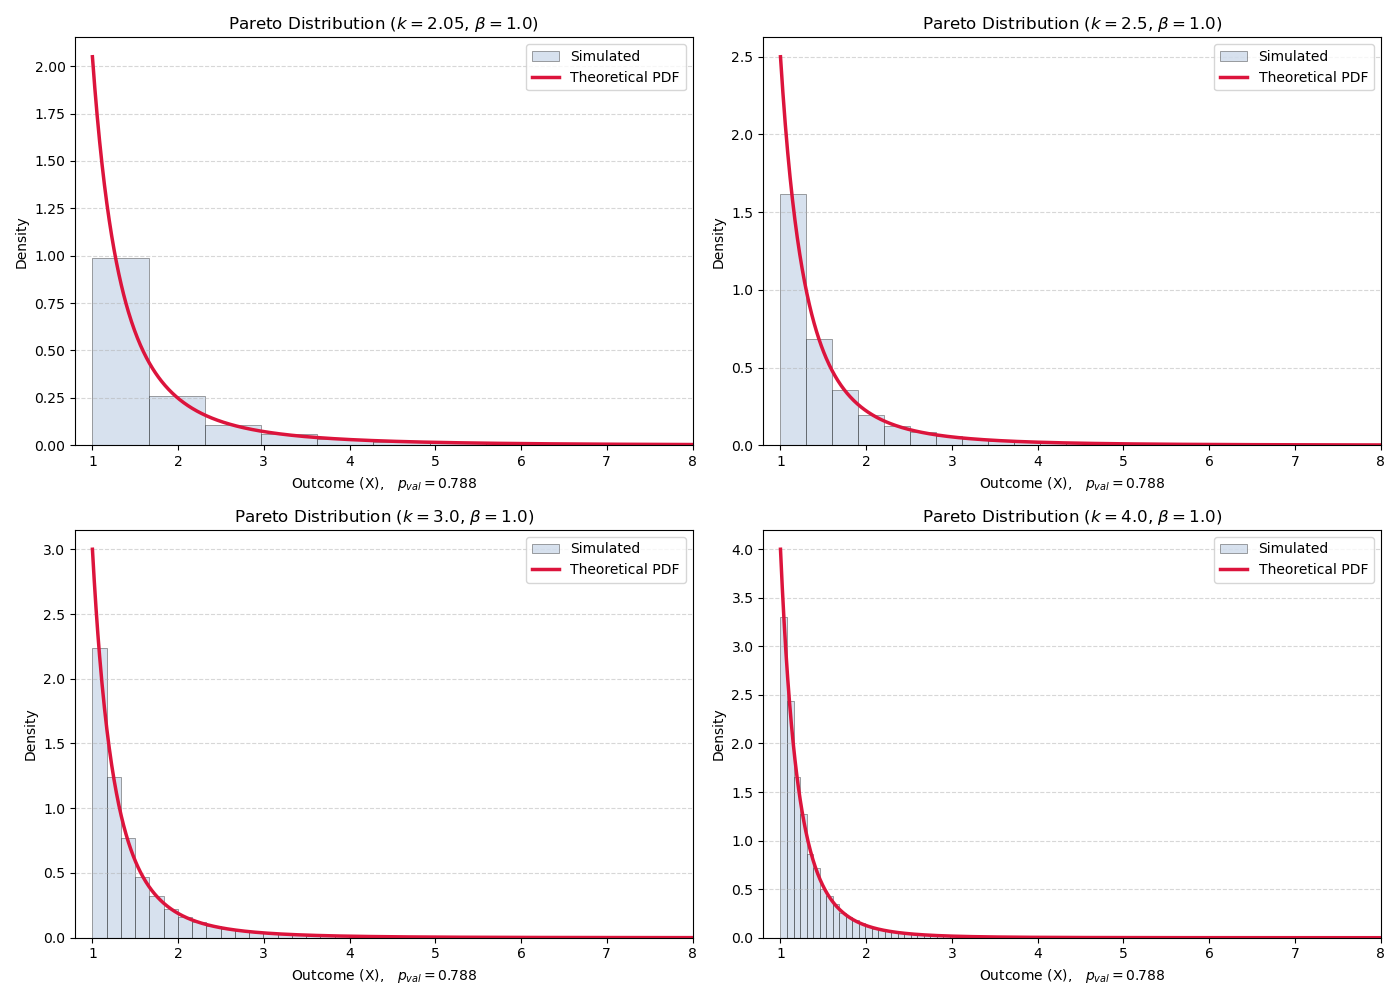

  P-value:          0.78796


In [33]:
# --- Helper Function for a Single Subplot ---
np.random.seed(33)
def plot_pareto_subplot(ax, samples, x_vals, beta, k, p_val):
    
    theoretical_pdf = (k * (beta**k)) / (x_vals ** (k + 1))

    ax.hist(
        samples,
        bins=100,
        density=True,
        alpha=0.5,
        color="lightsteelblue",
        edgecolor="black",
        linewidth=0.5,
        label="Simulated",
    )

    ax.plot(
        x_vals,
        theoretical_pdf,
        color="crimson",
        linewidth=2.5,
        label="Theoretical PDF",
    )

    # 4. Decorate the specific subplot
    ax.set_title(f"Pareto Distribution ($k = {k}$, $\\beta = {beta}$)")
    ax.set_xlabel(f"Outcome (X),$\quad p_{{val}} = {p_val:.3f}$")
    ax.set_ylabel("Density")
    ax.set_xlim(0.8, 8.0)  # Clamp axis to keep visualization clean
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.legend()


# --- Main Execution Block ---

N = 10_000
beta = 1.0
k_values = np.array([2.05, 2.5, 3.0, 4.0])

# Initialize matrix and generate uniform base
samples_pareto = np.zeros((N, len(k_values)))
U = np.random.uniform(0, 1, N)

# Generate the data columns
for i, k in enumerate(k_values):
    samples_pareto[:, i] = beta * (U) ** (-1.0 / k)

# Create a dense evaluation grid for the theoretical curves
x_dense = np.linspace(beta, 8.0, 1000)



p_vals = []
# KS Test 
for i, k in enumerate(k_values):
    current_samples = samples_pareto[:, i]

    # Define the theoretical Pareto distribution object as a variable
    # SciPy's Pareto requires: shape (k) and scale (beta)
    theoretical_pareto_dist = stats.pareto(b=k, scale=beta)

    # Run the test against this specific parameter's CDF
    ks_statistic, p_value = stats.kstest(
        current_samples, theoretical_pareto_dist.cdf
    )

    # Print results formatted cleanly
    print(f"\nFor Shape k = {k}:")
    print(f"  KS Statistic (D): {ks_statistic:.5f}")
    p_vals.append(p_value)

# Plot: Grid structure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Flatten the 2x2 axes matrix into a 1D array of 4 elements for easy looping 
axes_flat = axes.flatten()

for i, k in enumerate(k_values):
    # Pass the specific axis object along with the data column to our subplot function
    plot_pareto_subplot(
        ax=axes_flat[i],
        samples=samples_pareto[:, i],
        x_vals=x_dense,
        beta=beta,
        k=k,
        p_val= p_vals[i]
    )

plt.tight_layout()
plt.show()
print(f"  P-value:          {p_value:.5f}")

In [34]:
results = []

for i, k in enumerate(k_values):
    current_samples = samples_pareto[:, i]

    sample_mean = np.mean(current_samples)
    sample_var = np.var(current_samples, ddof=1)  # unbiased sample variance

    theoretical_mean = beta * k / (k - 1) if k > 1 else np.inf
    theoretical_var = beta**2 * k / ((k - 1)**2 * (k - 2)) if k > 2 else np.inf

    results.append({
        "k": k,
        "Sample mean": sample_mean,
        "Theoretical mean": theoretical_mean,
        "Mean error": sample_mean - theoretical_mean,
        "Sample variance": sample_var,
        "Theoretical variance": theoretical_var,
        "Variance error": sample_var - theoretical_var,
    })

moment_table = pd.DataFrame(results)
moment_table

,k,Sample mean,Theoretical mean,Mean error,Sample variance,Theoretical variance,Variance error
0,2.05,1.939109,1.952381,-0.013272,4.721626,37.188209,-32.466582
1,2.50,1.662018,1.666667,-0.004649,1.499592,2.222222,-0.722630
2,3.00,1.497871,1.500000,-0.002129,0.635348,0.750000,-0.114652
3,4.00,1.332508,1.333333,-0.000826,0.209067,0.222222,-0.013155


In [ ]:
from scipy.stats import t, chi2

# Settings
alpha = 0.05
n = 10
m = 100

mu = 0
sigma = 1
true_var = sigma**2

# generate 100 samples, each with 10 observations
samples = np.random.normal(mu, sigma, size=(n, m))

# Sample mean and sample variance for each column
xbar = np.mean(samples, axis=0)
s2 = np.var(samples, axis=0, ddof=1)
s = np.sqrt(s2)

df = n - 1

# CI Mean

t_value = t.ppf(1 - alpha/2, df)

lower_mean = xbar - t_value * s / np.sqrt(n)
upper_mean = xbar + t_value * s / np.sqrt(n)

mean_coverage = np.sum((lower_mean <= mu) & (upper_mean >= mu))

print(f"The true mean {mu} is inside {mean_coverage} out of {m} confidence intervals.")

The true mean 0 is inside 95 out of 100 confidence intervals.


In [ ]:
# CI Variance

chi2_lower = chi2.ppf(alpha/2, df)
chi2_upper = chi2.ppf(1 - alpha/2, df)

lower_var = (df * s2) / chi2_upper
upper_var = (df * s2) / chi2_lower

var_coverage = np.sum((lower_var <= true_var) & (upper_var >= true_var))

print(f"The true variance {true_var} is inside {var_coverage} out of {m} confidence intervals.")

The true variance 1 is inside 97 out of 100 confidence intervals.


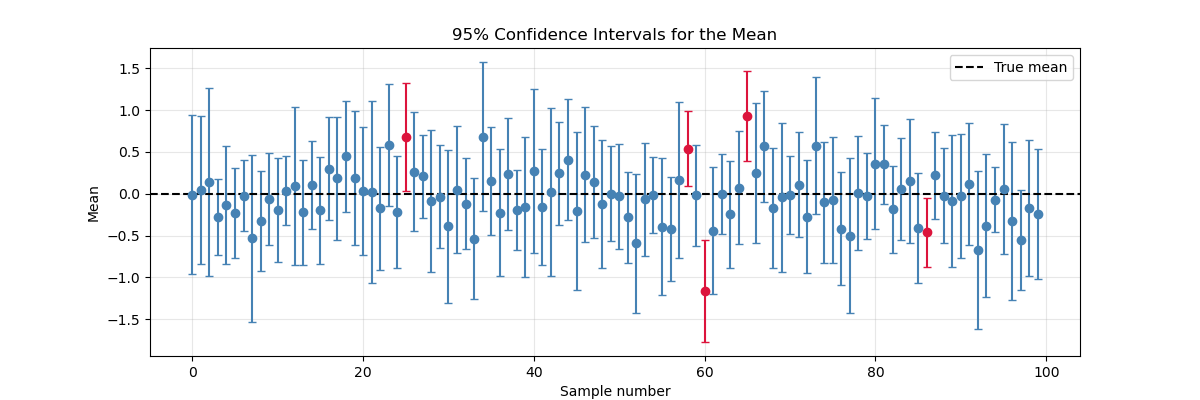

In [37]:
plt.figure(figsize=(12, 4))

for i in range(m):
    if lower_mean[i] <= mu <= upper_mean[i]:
        color = "steelblue"
    else:
        color = "crimson"

    plt.errorbar(
        i, xbar[i],
        yerr=[[xbar[i] - lower_mean[i]], [upper_mean[i] - xbar[i]]],
        fmt='o',
        capsize=3,
        color=color
    )

plt.axhline(mu, linestyle='--', color='black', label='True mean')
plt.xlabel("Sample number")
plt.ylabel("Mean")
plt.title("95% Confidence Intervals for the Mean")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

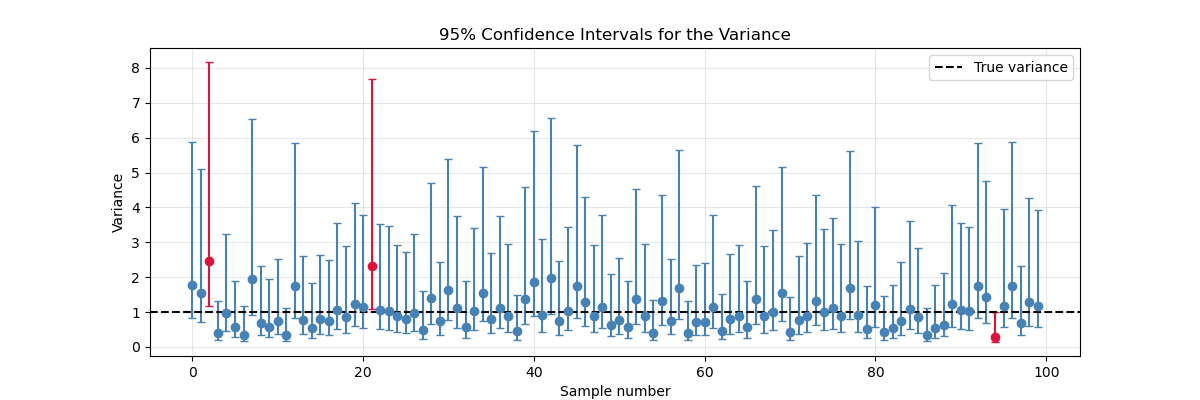

In [38]:
plt.figure(figsize=(12, 4))

for i in range(m):
    if lower_var[i] <= true_var <= upper_var[i]:
        color = "steelblue"
    else:
        color = "crimson"

    plt.errorbar(
        i,
        s2[i],
        yerr=[[s2[i] - lower_var[i]], [upper_var[i] - s2[i]]],
        fmt='o',
        capsize=3,
        color=color
    )

plt.axhline(true_var, linestyle='--', color='black', label='True variance')
plt.xlabel("Sample number")
plt.ylabel("Variance")
plt.title("95% Confidence Intervals for the Variance")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### Composition method Pareto Simulation

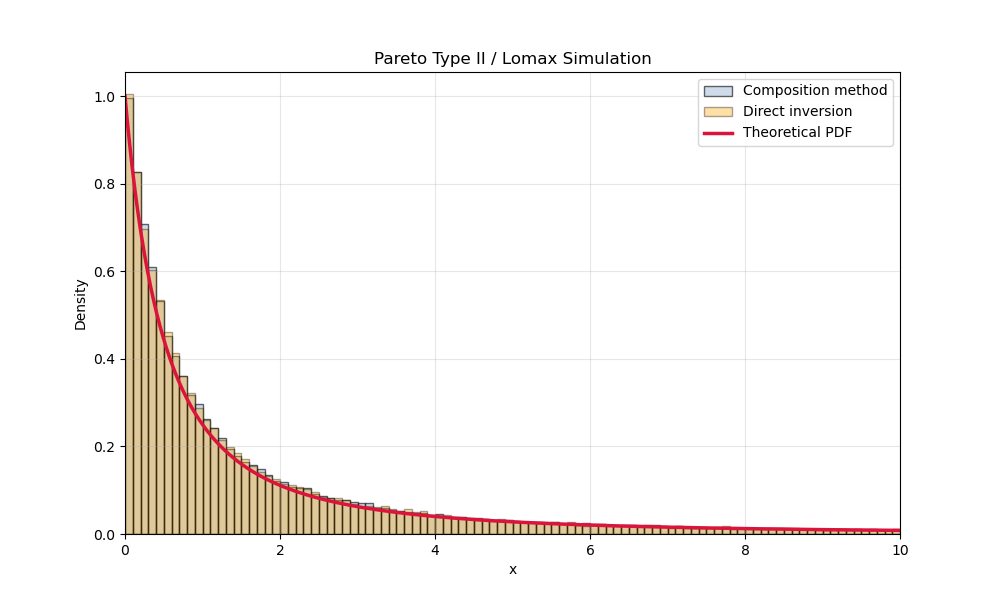

In [52]:
mu = 1

Y = np.random.exponential(scale=1/mu, size=N)
X_composition = np.random.exponential(scale=1/Y)

U = np.random.uniform(0, 1, N)
X_direct = mu * U / (1 - U)

x_vals = np.linspace(0, 10, 1000)
theoretical_pdf = mu / (mu + x_vals)**2

plt.figure(figsize=(10, 6))

plt.hist(
    X_composition, bins=100, range=(0, 10), density=True,
    alpha=0.6, color="lightsteelblue", edgecolor="black",
    label="Composition method"
)

plt.hist(
    X_direct, bins=100, range=(0, 10), density=True,
    alpha=0.35, color="orange", edgecolor="black",
    label="Direct inversion"
)

plt.plot(
    x_vals, theoretical_pdf,
    color="crimson", linewidth=2.5,
    label="Theoretical PDF"
)

plt.xlim(0, 10)
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Pareto Type II / Lomax Simulation")
plt.legend()
plt.grid(alpha=0.3)
plt.show()